In [8]:
import numpy as np
import pandas as pd
from SERGIO.sergio import sergio

In [6]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict

def generate_fixed_k_grn(filename, num_tfs, num_genes, targets_per_tf, fixed_k, fixed_hill):
    """
    Generates a GRN where the ONLY variable is the network topology (who regulates whom).
    K and Hill are constants to ensure they do not influence correlation.
    """
    # target_id -> list of (regulator_id, k, hill)
    gene_map = defaultdict(list)
    
    tf_ids = list(range(num_tfs))
    target_gene_ids = list(range(num_tfs, num_tfs + num_genes))
    
    # Track which genes have been assigned at least once to ensure no "dead" genes
    assigned_genes = set()

    for tf_id in tf_ids:
        # 1. Determine fan-out (number of genes this TF controls)
        n_targets = random.randint(targets_per_tf[0], targets_per_tf[1])
        
        # 2. Randomly select the targets for this TF
        selected_targets = random.sample(target_gene_ids, n_targets)
        
        # 3. Apply the FIXED parameters to every gene in this TF's regulon
        for target_id in selected_targets:
            gene_map[target_id].append((tf_id, fixed_k, fixed_hill))
            assigned_genes.add(target_id)

    # 4. Cleanup: If any genes were missed by random sampling, assign them to a random TF
    # This prevents the simulator from crashing or having "zero-expression" features
    unassigned = set(target_gene_ids) - assigned_genes
    for target_id in unassigned:
        random_tf = random.choice(tf_ids)
        gene_map[target_id].append((random_tf, fixed_k, fixed_hill))

    # 5. Format for CSV: [target_id, n_regs, TFs..., Ks..., Hills...]
    rows = []
    for target_id in sorted(gene_map.keys()):
        regs_data = gene_map[target_id]
        n_regs = len(regs_data)
        
        tfs = [float(r[0]) for r in regs_data]
        ks = [float(r[1]) for r in regs_data]
        hills = [float(r[2]) for r in regs_data]
        
        row = [float(target_id), float(n_regs)] + tfs + ks + hills
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False, header=False)
    print(f"Success: {filename} generated.")
    print(f"Stats: {num_tfs} TFs, {num_genes} Genes. Constant K={fixed_k}, Hill={fixed_hill}")

# --- EXPERIMENTAL RUNS ---

# 2. LOW CORRELATION DATASET
# Low Fan-out: Each TF controls a tiny, near-unique sliver of genes
generate_fixed_k_grn(
    filename='50_60_target.csv',
    num_tfs=30,
    num_genes=270,
    targets_per_tf=(50, 60),
    fixed_k=2.5, 
    fixed_hill=2.0
)

Success: 50_60_target.csv generated.
Stats: 30 TFs, 270 Genes. Constant K=2.5, Hill=2.0


In [1]:
import pandas as pd
import numpy as np
import random

def generate_variance_controlled_basal(num_tfs, num_cell_types, mode="high"):
    """
    mode: "high" for high inter-class variance (clear separation)
          "low" for low inter-class variance (overlapping/difficult separation)
    """
    tf_ids = list(range(num_tfs))
    random.shuffle(tf_ids)

    # Biological Proportions
    hk_count   = int(num_tfs * 0.20)
    rand_count = int(num_tfs * 0.30)
    spec_count = num_tfs - hk_count - rand_count

    hk_ids   = tf_ids[:hk_count]
    rand_ids = tf_ids[hk_count:hk_count + rand_count]
    spec_ids = tf_ids[hk_count + rand_count:]

    all_rows = []

    # 1. Housekeeping: Stable baseline
    # No change between modes - HK should remain a control variable.
    for tf_id in hk_ids:
        base_rate = np.random.lognormal(mean=0.8, sigma=0.1) 
        row = [float(tf_id)] + [round(base_rate, 3)] * num_cell_types
        all_rows.append(row)

    # 2. Random/Noisy: Background interference
    for tf_id in rand_ids:
        rates = []
        for _ in range(num_cell_types):
            # In LOW variance mode, we increase noise to further blur the classes
            dropout_prob = 0.6 if mode == "high" else 0.3 
            scale_val = 0.5 if mode == "high" else 1.2
            
            if random.random() < dropout_prob:
                rates.append(0.0)
            else:
                rates.append(round(np.random.exponential(scale=scale_val), 3))
        row = [float(tf_id)] + rates
        all_rows.append(row)

    # 3. Cell-Type Specific (CTS): The Driver of Variance
    index = 0
    tfs_per_type = spec_count // num_cell_types
    
    for ct in range(num_cell_types):
        count = tfs_per_type + (1 if ct < (spec_count % num_cell_types) else 0)
        batch = spec_ids[index:index + count]
        index += count

        for tf_id in batch:
            if mode == "high":
                # HIGH VARIANCE: Binary-like behavior (Master Regulators)
                # Primary is very high, others are practically zero
                rates = [round(random.uniform(0.0, 0.01), 3) for _ in range(num_cell_types)]
                rates[ct] = round(np.random.gamma(shape=5.0, scale=4.0), 3) # High Mean
                
                # Sharp lineage transition (minimal leaking)
                neighbor = (ct + 1) % num_cell_types
                rates[neighbor] = round(rates[ct] * random.uniform(0.05, 0.1), 3)
            
            else:
                # LOW VARIANCE: Gradient behavior (Subtle Differentiation)
                # Global mean is similar; primary is only slightly higher than background
                base_val = 5.0 
                rates = [round(np.random.normal(base_val, 0.5), 3) for _ in range(num_cell_types)]
                
                # The "Peak" is only 1.5x - 2x higher than the background
                rates[ct] = round(base_val * random.uniform(1.5, 2.0), 3)
                
                # Heavy lineage leaking (blurs the boundary between classes)
                neighbor = (ct + 1) % num_cell_types
                rates[neighbor] = round(rates[ct] * random.uniform(0.7, 0.9), 3)
            
            row = [float(tf_id)] + rates
            all_rows.append(row)

    all_rows.sort(key=lambda x: x[0])
    df = pd.DataFrame(all_rows)
    filename = f"basal_regs_{mode}_variance.csv"
    df.to_csv(filename, index=False, header=False)
    print(f"Generated {filename} with {num_tfs} TFs.")

# Generate both sets for comparison
generate_variance_controlled_basal(num_tfs=30, num_cell_types=5, mode="high")
generate_variance_controlled_basal(num_tfs=30, num_cell_types=5, mode="low")

Generated basal_regs_high_variance.csv with 30 TFs.
Generated basal_regs_low_variance.csv with 30 TFs.


# Simulate Clean Data _ Steady-State Simulation

sim = sergio(number_genes=100, number_bins = 9, number_sc = 300, noise_params = 1, decays=0.8, sampling_state=15, noise_type='dpd')
sim.build_graph(input_file_taregts ='data_sets/De-noised_100G_9T_300cPerT_4_DS1/Interaction_cID_4.txt', input_file_regs='data_sets/De-noised_100G_9T_300cPerT_4_DS1/Regs_cID_4.txt', shared_coop_state=2)
sim.simulate()
expr = sim.getExpressions()
expr_clean = np.concatenate(expr, axis = 1)

In [45]:
sim = sergio(number_genes=30+270, number_bins = 5, number_sc = 500, noise_params = 1, decays=0.8, sampling_state=15, noise_type='dpd')
sim.build_graph(input_file_taregts ='1_3_target.csv', input_file_regs='basal_regs_low_variance.csv', shared_coop_state=2)
sim.simulate()
expr = sim.getExpressions()
expr_clean = np.concatenate(expr, axis = 1)

Start simulating new level
There are 30 genes to simulate in this layer
Done with current level
Start simulating new level
There are 270 genes to simulate in this layer
Done with current level


# Add Technical Noise _ Steady-State Simulations

In [46]:
"""
Add outlier genes
"""
expr_O = sim.outlier_effect(expr, outlier_prob = 0.01, mean = 0.8, scale = 1)

"""
Add Library Size Effect
"""
libFactor, expr_O_L = sim.lib_size_effect(expr_O, mean = 4.6, scale = 0.4)

"""
Add Dropouts
"""
binary_ind = sim.dropout_indicator(expr_O_L, shape = 6.5, percentile = 82)
expr_O_L_D = np.multiply(binary_ind, expr_O_L)

"""
Convert to UMI count
"""
count_matrix = sim.convert_to_UMIcounts(expr_O_L_D)

"""
Make a 2d gene expression matrix
"""
count_matrix = np.concatenate(count_matrix, axis = 1)

In [47]:
count_matrix

array([[3, 1, 2, ..., 1, 0, 2],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 2500))

In [48]:
np.save("1_3_gene_low_var_sergio.npy", count_matrix)

In [15]:
import numpy as np
np_df = np.load('1_3_gene_sergio.npy')
np_df

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 3, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(300, 2500))

In [16]:
import anndata as ad
import scanpy as sc
import pandas as pd

gene_names = [f"Gene_{i+1}" for i in range(300)]
cell_names = [f"Cell_{i+1}" for i in range(2500)]
cell_types = [f"Type{(i // 500) + 1}" for i in range(2500)]

adata = ad.AnnData(
    X=np_df.T,
    obs=pd.DataFrame(
        {
            "cell_type": cell_types
        },
        index=cell_names
    ),
    var=pd.DataFrame(index=gene_names)
)
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
adata.obs["tf_mean"] = np.asarray(
    adata[:, :100].X.mean(axis=1)
).ravel()
adata.obs["gene_mean"] = np.asarray(
    adata[:, 100:].X.mean(axis=1)
).ravel()
adata

AnnData object with n_obs × n_vars = 2500 × 300
    obs: 'cell_type', 'tf_mean', 'gene_mean'
    uns: 'log1p'

In [17]:
adata.obs

,cell_type,tf_mean,gene_mean
Cell_1,Type1,0.134788,0.086916
Cell_2,Type1,0.138631,0.125047
Cell_3,Type1,0.167107,0.136092
Cell_4,Type1,0.182341,0.107075
Cell_5,Type1,0.121170,0.121996
...,...,...,...
Cell_2496,Type5,0.126821,0.061315
Cell_2497,Type5,0.138402,0.099880
Cell_2498,Type5,0.109730,0.072935
Cell_2499,Type5,0.134052,0.071761


In [18]:
sc.tl.pca(adata, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata, log=True)
# Step 3: Compute neighbors
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-29 14:45:51.400638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 14:45:54.044782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 14:46:01.635394: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see

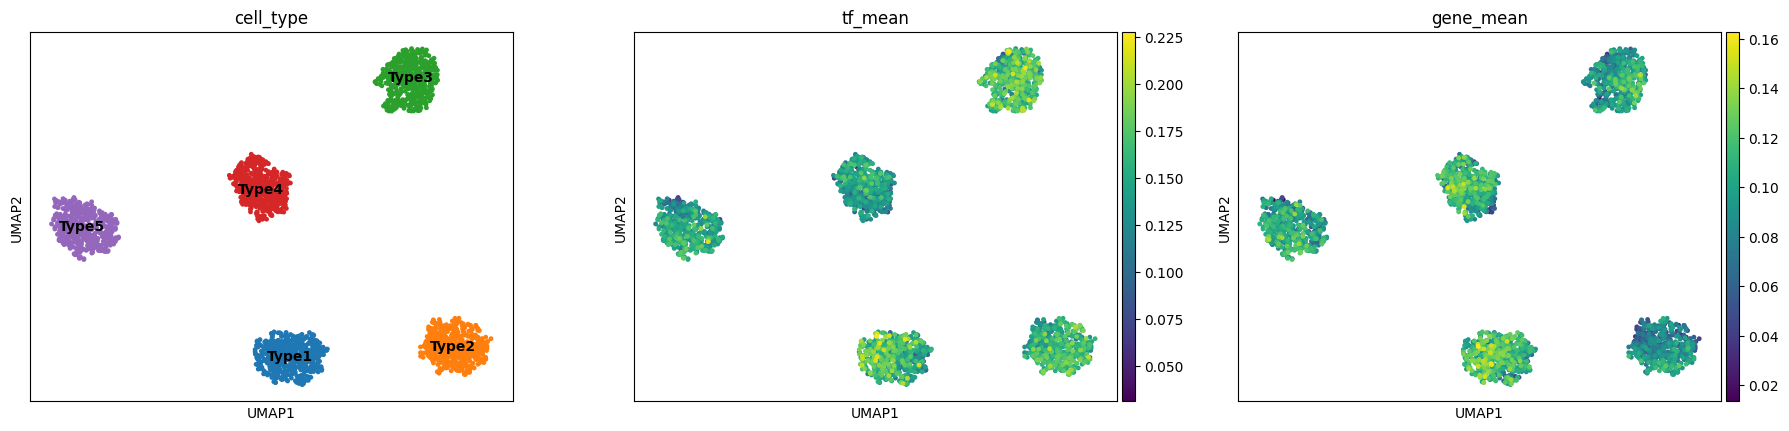

In [19]:
sc.pl.umap(
        adata,
        color=['cell_type', 'tf_mean', 'gene_mean'],
        legend_loc="on data",
        show=True,
        save=f"_1_3_gene_sergio.png"
    )

In [8]:
adata.X.T

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.81676114, 0.        ,
        0.        ],
       [0.        , 0.3294792 , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(300, 2500), dtype=float32)

In [49]:
import numpy as np
import pandas as pd
from pathlib import Path

# ===== USER SETTINGS =====
NPY_FOLDER = "./"   # <- CHANGE THIS
BLOCK_SIZE = 500   # cells per label type
# =========================


for npy_path in sorted(Path(NPY_FOLDER).glob("*.npy")):

    print("Processing:", npy_path.name)

    # Load matrix (genes x cells)
    data = np.load(npy_path)
    n_genes, n_cells = data.shape

    # Transpose -> cells x genes
    data = data.T

    # Build names
    gene_names = [f"Gene_{i+1}" for i in range(n_genes)]
    cell_names = [f"Cell_{i+1}" for i in range(n_cells)]

    # Build expression DataFrame
    expr_df = pd.DataFrame(data, index=cell_names, columns=gene_names)

    # Output filenames
    expr_out = npy_path.with_suffix(".csv")
    label_out = npy_path.with_name(f"meta_{npy_path.stem}.csv")

    # Save expression
    expr_df.to_csv(expr_out)

    # Generate labels
    labels = [f"Type{(i // BLOCK_SIZE) + 1}" for i in range(n_cells)]
    meta_df = pd.DataFrame({"": cell_names, "Label": labels})

    # Save labels
    meta_df.to_csv(label_out, index=False)

    print("Saved:", expr_out.name, "and", label_out.name)

print("All files processed.")

Processing: 1_3_gene_high_var_sergio.npy
Saved: 1_3_gene_high_var_sergio.csv and meta_1_3_gene_high_var_sergio.csv
Processing: 1_3_gene_low_var_sergio.npy
Saved: 1_3_gene_low_var_sergio.csv and meta_1_3_gene_low_var_sergio.csv
Processing: 20_30_gene_high_var_sergio.npy
Saved: 20_30_gene_high_var_sergio.csv and meta_20_30_gene_high_var_sergio.csv
Processing: 20_30_gene_low_var_sergio.npy
Saved: 20_30_gene_low_var_sergio.csv and meta_20_30_gene_low_var_sergio.csv
Processing: 50_60_gene_high_var_sergio.npy
Saved: 50_60_gene_high_var_sergio.csv and meta_50_60_gene_high_var_sergio.csv
Processing: 50_60_gene_low_var_sergio.npy
Saved: 50_60_gene_low_var_sergio.csv and meta_50_60_gene_low_var_sergio.csv
Processing: 5_10_gene_high_var_sergio.npy
Saved: 5_10_gene_high_var_sergio.csv and meta_5_10_gene_high_var_sergio.csv
Processing: 5_10_gene_low_var_sergio.npy
Saved: 5_10_gene_low_var_sergio.csv and meta_5_10_gene_low_var_sergio.csv
All files processed.
